In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

sns.set_theme(style="whitegrid")

iris = load_iris()

df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("Dataset Shape")
print(df.shape)

print("\nMissing Values Check")
print(df.isnull().sum())

print("\nFirst 5 Rows")
df.head()

Dataset Shape
(150, 5)

Missing Values Check
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

First 5 Rows


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Statistical Summary


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Class Distribution
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


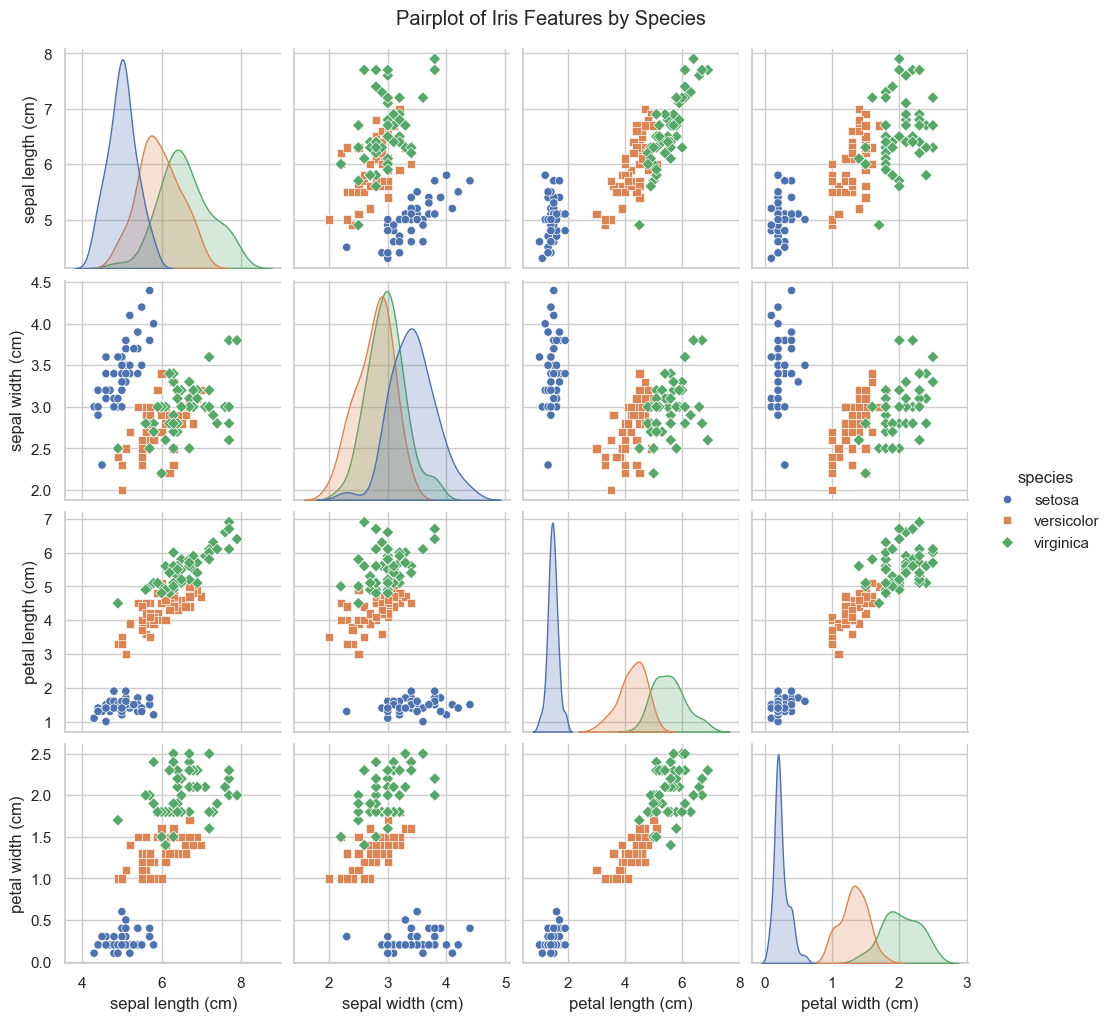

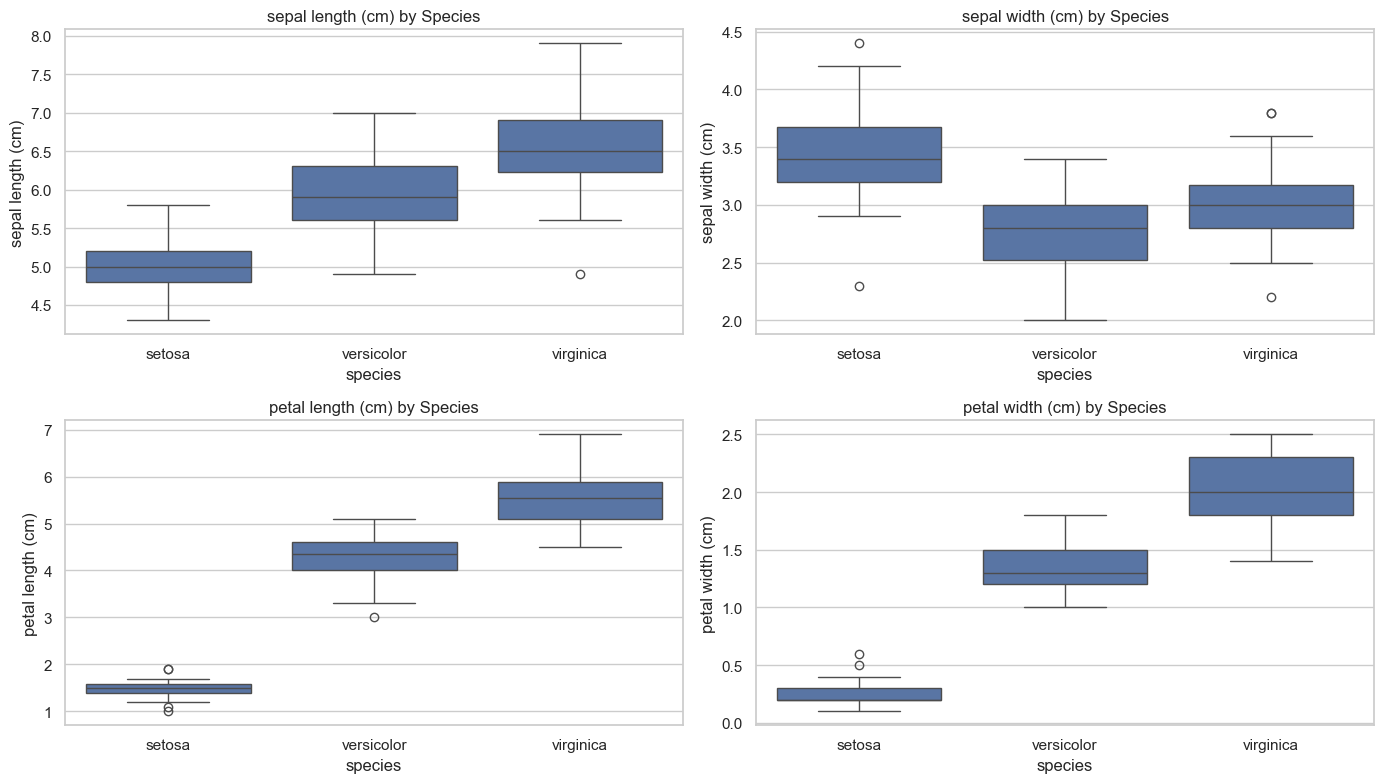

In [7]:
print("Statistical Summary")
display(df.describe())

print("\nClass Distribution")
print(df['species'].value_counts())

sns.pairplot(df, hue='species', markers=["o", "s", "D"])
plt.suptitle("Pairplot of Iris Features by Species", y=1.02)
plt.show()

plt.figure(figsize=(14, 8))
features = iris.feature_names

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='species', y=feature, data=df)
    plt.title(f"{feature} by Species")

plt.tight_layout()
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

lr_model = LogisticRegression(max_iter=200, random_state=42)
lr_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("\nBoth models successfully trained!")

Training samples: 120
Testing samples: 30

Both models successfully trained!


Logistic Regression Accuracy: 0.9667
Random Forest Accuracy:       0.9000

Logistic Regression Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Random Forest Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



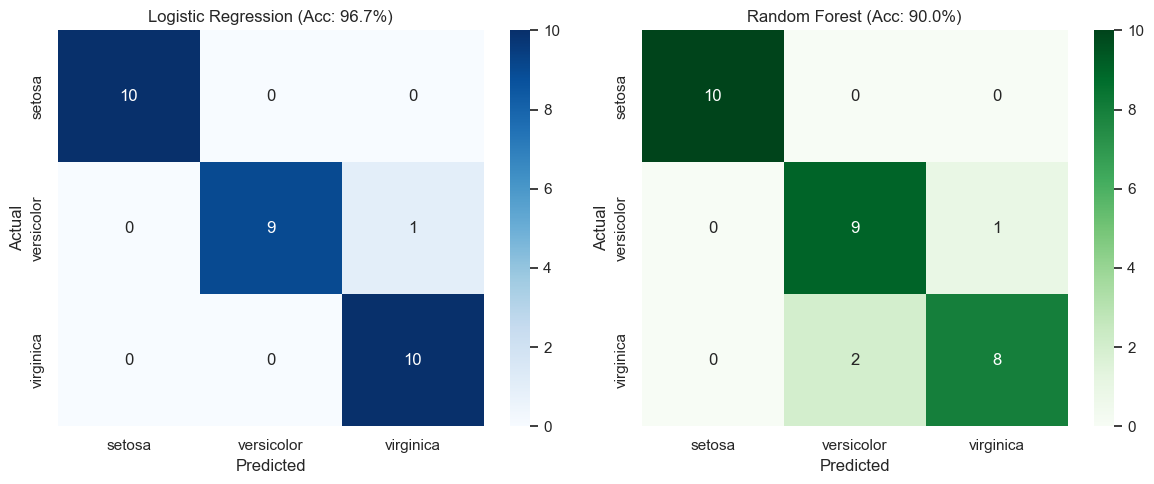

Conclusion: Logistic Regression achieves top performance with clean linear separation.


In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Logistic Regression Accuracy: {acc_lr:.4f}")
print(f"Random Forest Accuracy:       {acc_rf:.4f}")

print("\nLogistic Regression Classification Report")
print(classification_report(y_test, y_pred_lr, target_names=iris.target_names))

print("\nRandom Forest Classification Report")
print(classification_report(y_test, y_pred_rf, target_names=iris.target_names))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names, ax=axes[0])
axes[0].set_title(f"Logistic Regression (Acc: {acc_lr*100:.1f}%)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens',
            xticklabels=iris.target_names, yticklabels=iris.target_names, ax=axes[1])
axes[1].set_title(f"Random Forest (Acc: {acc_rf*100:.1f}%)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

if acc_rf >= acc_lr:
    print("Conclusion: Random Forest performs robustly across all classes with high discriminative power.")
else:
    print("Conclusion: Logistic Regression achieves top performance with clean linear separation.")